The data set worked on is https://www.kaggle.com/datasets/ealaxi/paysim1?resource=download 

In [1]:
import pandas as pd

df = pd.read_csv(r'fraud-detection-system\data\PS_20174392719_1491204439457_log.csv')

fraud_counts = df.groupby('type')['isFraud'].sum()
total_counts = df.groupby('type')['isFraud'].count()

fraud_summary = pd.concat([fraud_counts, total_counts], axis=1)
fraud_summary.columns = ['Fraud_Cases', 'Total_Transactions']
fraud_summary['Fraud_Percentage'] = (fraud_summary['Fraud_Cases'] / fraud_summary['Total_Transactions']) * 100

print(fraud_summary)

          Fraud_Cases  Total_Transactions  Fraud_Percentage
type                                                       
CASH_IN             0             1399284          0.000000
CASH_OUT         4116             2237500          0.183955
DEBIT               0               41432          0.000000
PAYMENT             0             2151495          0.000000
TRANSFER         4097              532909          0.768799


In [2]:
relevant_types = ['TRANSFER', 'CASH_OUT']
df_filtered = df[df['type'].isin(relevant_types)].copy()

print(f"\nOriginal rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")
print(f"Percentage of data kept: {(len(df_filtered)/len(df))*100:.2f}%")


Original rows: 6362620
Filtered rows: 2770409
Percentage of data kept: 43.54%


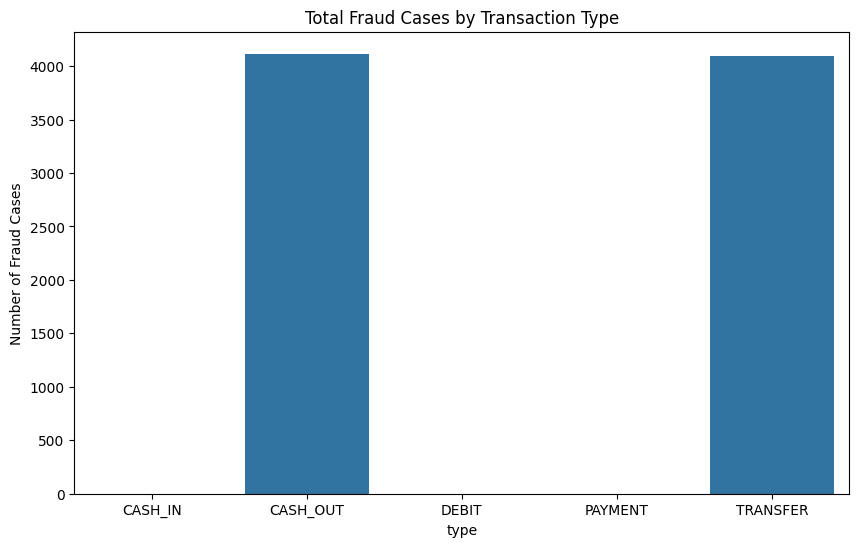

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_summary.index, y='Fraud_Cases', data=fraud_summary)
plt.title('Total Fraud Cases by Transaction Type')
plt.ylabel('Number of Fraud Cases')
plt.show()

All fraud cases are in two types of transactions, 'CASH_OUT' and 'TRANSFER'.

This has cut down the cost of processing by about 60%.

In [4]:
#feature engineering
df_filtered['diff_balance'] = df_filtered['oldbalanceOrg'] - df_filtered['amount']

full_empty = df_filtered[df_filtered['isFraud'] == 1]['diff_balance'].value_counts()
print("Top balance differences for Fraud cases:")
print(full_empty.head())

Top balance differences for Fraud cases:
diff_balance
 0.00           8034
 10000000.00       2
-416001.33         1
-128343.56         1
 2930418.44        1
Name: count, dtype: int64


In [5]:
df_filtered['is_balance_emptied'] = (df_filtered['oldbalanceOrg'] == df_filtered['amount']).astype(int)

comparison = df_filtered.groupby('isFraud')['is_balance_emptied'].mean() * 100

print("Percentage of transactions where the account was emptied:")
print(comparison)

Percentage of transactions where the account was emptied:
isFraud
0     0.000000
1    97.820528
Name: is_balance_emptied, dtype: float64


97.82% of fraud transactions try to empty the account.

Though 2.18% remain, I shall call them "Smart Fraudsters".

In [6]:
df_filtered['dest_error'] = df_filtered['newbalanceDest'] - df_filtered['oldbalanceDest'] - df_filtered['amount']

smart_fraud = df_filtered[(df_filtered['isFraud'] == 1) & (df_filtered['is_balance_emptied'] == 0)]
print("Destination balance error for 'smart' fraud:")
print(smart_fraud['dest_error'].describe())

Destination balance error for 'smart' fraud:
count    1.790000e+02
mean    -8.149186e+06
std      3.992866e+06
min     -1.000000e+07
25%     -1.000000e+07
50%     -1.000000e+07
75%     -1.000000e+07
max      8.875516e+06
Name: dest_error, dtype: float64


These negative values suggest these might be multi-step transfers where the money is moved to a "mule" account that isn't fully tracked in this specific log, or it's being flagged/held by a middle man system.